<a href="https://colab.research.google.com/github/ratneshpal700-ops/celebal-project/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/Country-data.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [2]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df['country'].nunique()

167

###EDA(Exploratory Data Analysis)

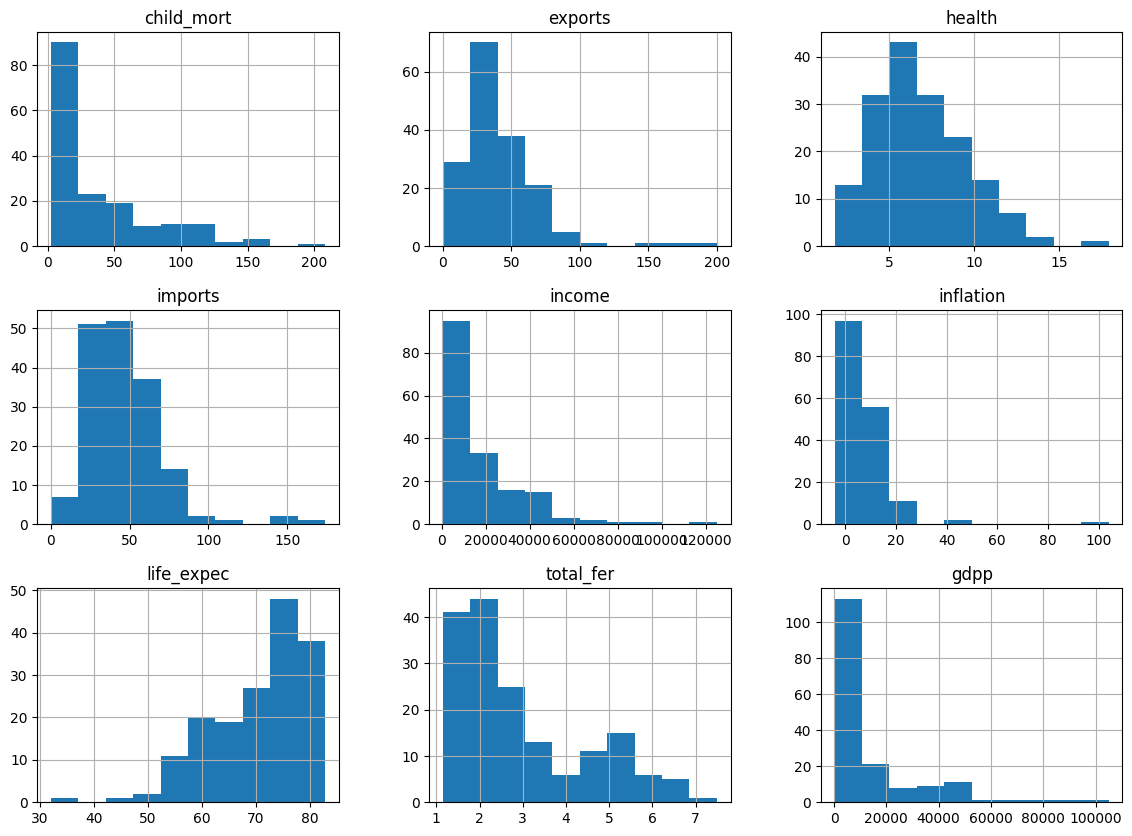

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(14,10))
plt.show()

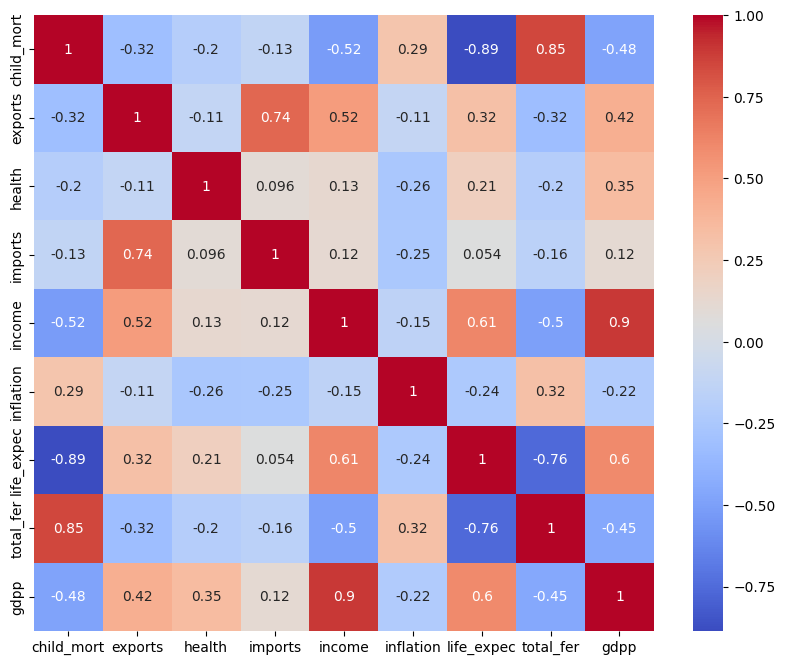

In [6]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

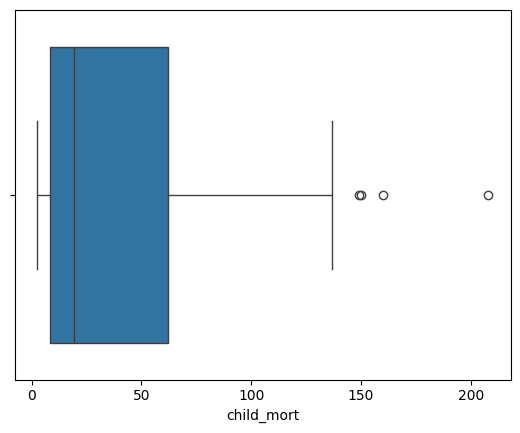

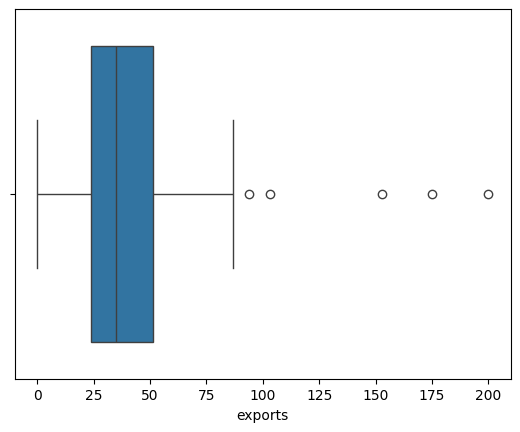

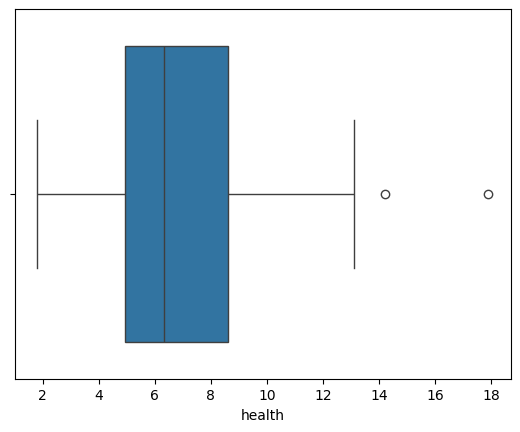

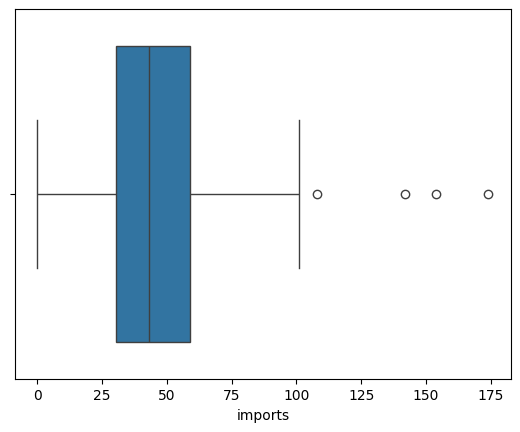

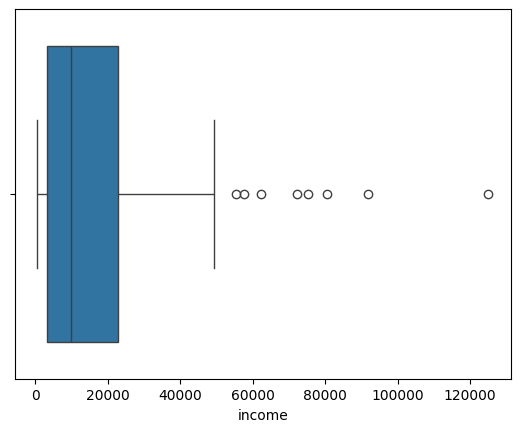

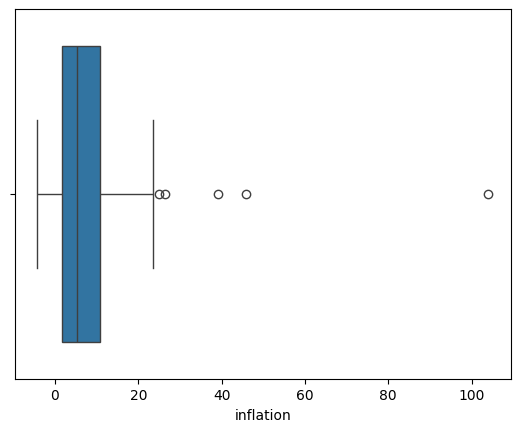

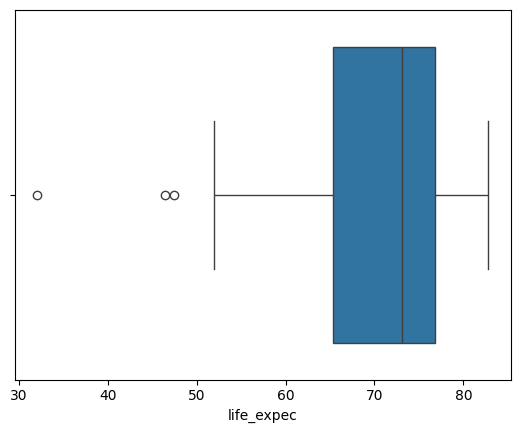

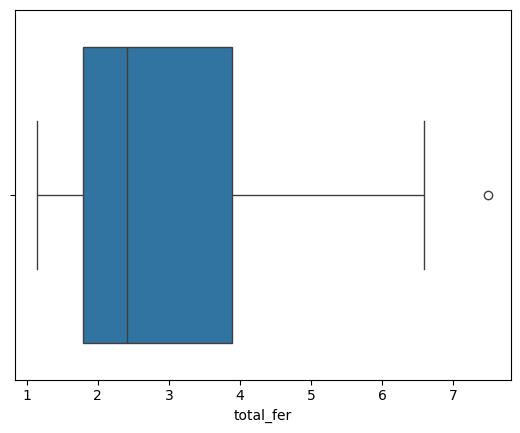

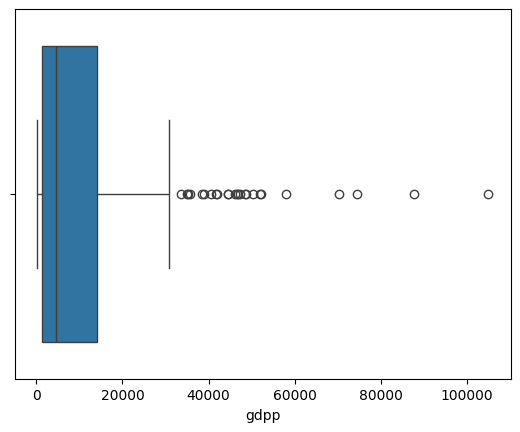

In [7]:
for col in df.columns[1:]:
    sns.boxplot(x=df[col])
    plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df.iloc[:,1:])

In [9]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2,11):

    kmeans = KMeans(n_clusters=i,
                    random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

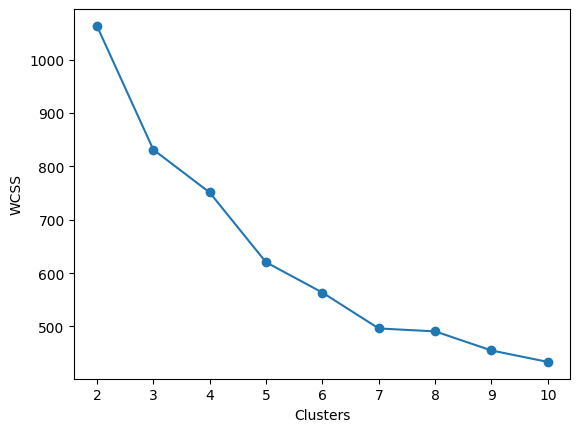

In [10]:
plt.plot(range(2,11),wcss,'o-')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

scores=[]

for i in range(2,11):

    model=KMeans(n_clusters=i,
                 random_state=42)

    labels=model.fit_predict(scaled_data)

    scores.append(silhouette_score(scaled_data,
                                   labels))

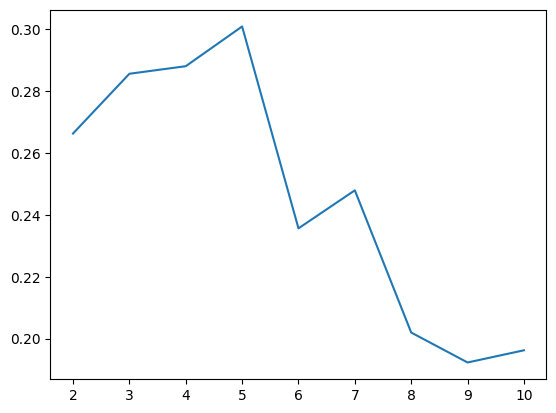

In [12]:
plt.plot(range(2,11),scores)
plt.show()

###Model Building

In [13]:
kmeans=KMeans(n_clusters=3,
              random_state=42)

df['Cluster']=kmeans.fit_predict(scaled_data)

###Cluster Visualization

In [14]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

components=pca.fit_transform(scaled_data)

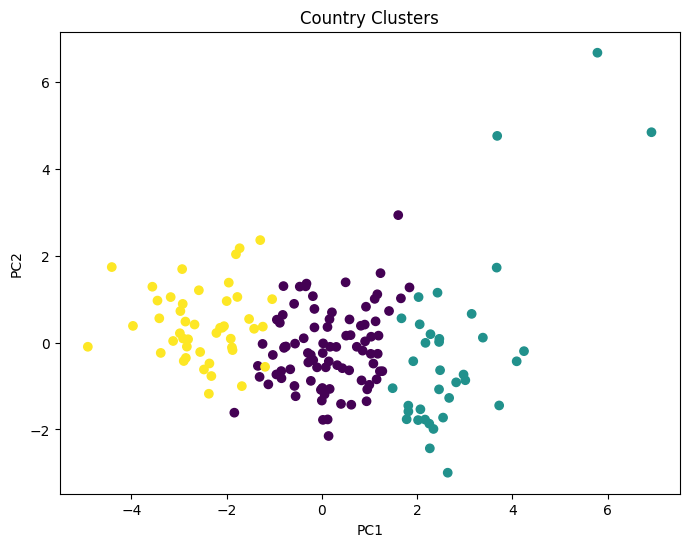

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(components[:,0],
            components[:,1],
            c=df['Cluster'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Country Clusters")

plt.show()

###Cluster Profiling

In [16]:
cluster_summary=df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


###Identify Countries Most in Need

In [17]:
df[df['Cluster']==2].sort_values(
    by=['gdpp','income']
)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231,2
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334,2
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348,2
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399,2
93,Madagascar,62.2,25.00,3.77,43.0,1390,8.790,60.8,4.60,413,2
106,Mozambique,101.0,31.50,5.21,46.2,918,7.640,54.5,5.56,419,2
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,2
94,Malawi,90.5,22.80,6.59,34.9,1030,12.100,53.1,5.31,459,2
50,Eritrea,55.2,4.79,2.66,23.3,1420,11.600,61.7,4.61,482,2


In [18]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.4595174  0.17181626]
0.6313336543771411


In [19]:
df["Cluster"].value_counts()

,count
Cluster,
0,86
2,45
1,36


<Axes: xlabel='Cluster', ylabel='count'>

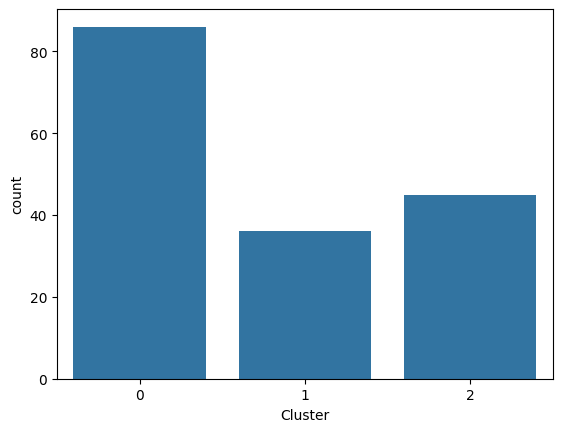

In [20]:
sns.countplot(x="Cluster", data=df)

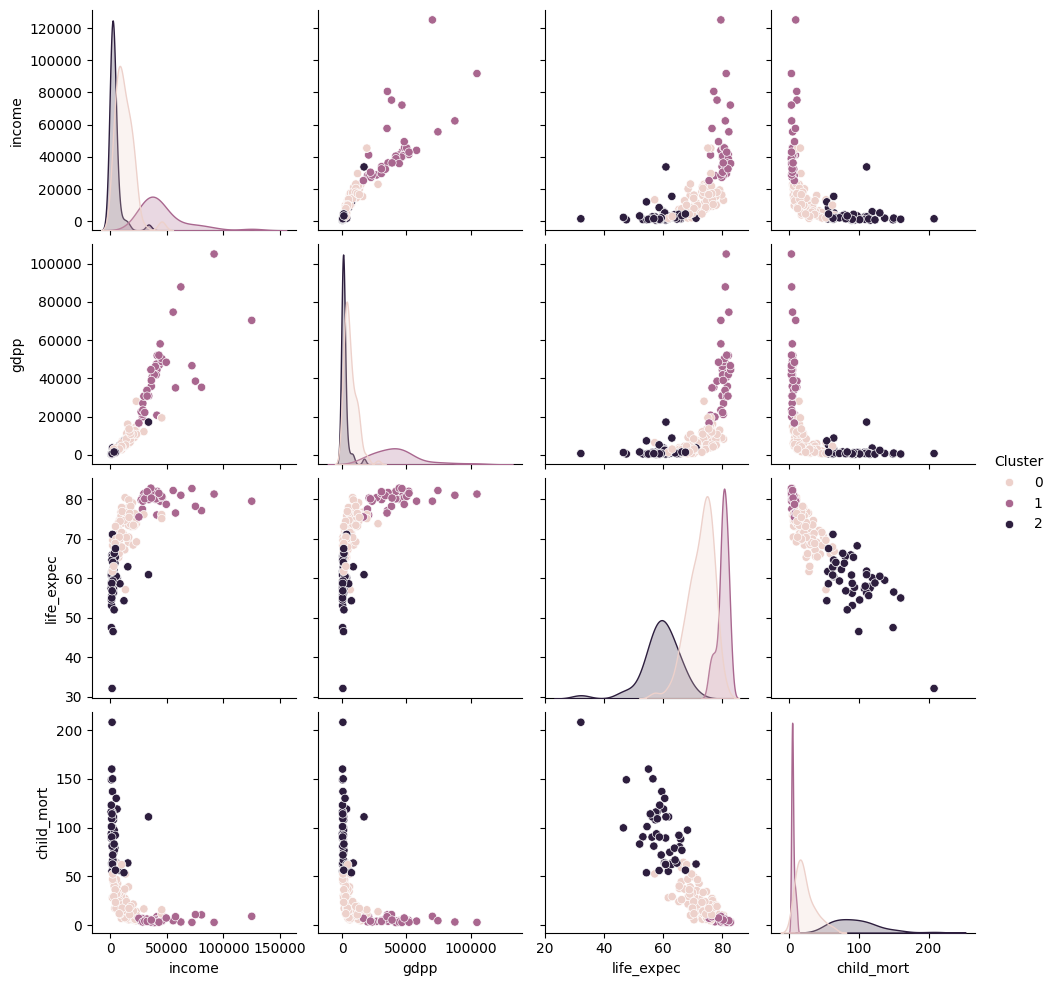

In [21]:
sns.pairplot(
    df,
    vars=["income","gdpp","life_expec","child_mort"],
    hue="Cluster"
)

###Final Insights and Conclusion
This project applied K-Means and DBSCAN clustering techniques to group countries based on socio-economic indicators.

K-Means successfully identified meaningful clusters, while PCA visualization helped interpret cluster separation. The analysis revealed distinct patterns among developed, developing, and high-mortality countries.

The results demonstrate how unsupervised learning techniques can uncover hidden structures in data and support data-driven decision-making.